# Gradient Descent Algorithm for Linear Regression Model

In [1]:
# Importing the Libraries
import numpy as np
import pandas as pd

In [2]:
# Loading the Datasets
df = pd.read_csv('Datasets/Advertising.csv')

In [3]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
# Setting X and Y variables
X = df[['TV', 'Radio', 'Newspaper']]
Y = df['Sales']

In [5]:
# Standardizing the Data
Y = np.array((Y - Y.mean()) / Y.std())
X = X.apply(lambda rec: (rec - rec.mean()) / rec.std(), axis=0)

### Implmenting Gradient Descent Algorithm
To implement the steps of Gradient Descent, a set of the following utility methods needs to be implemented.
1. Method 1: Method to randomly initialize the bias and weights.
2. Method 2: Method to calculate the predicted value of Y, that is, Y given the bias and weights.
3. Method 3: Method to calculate the cost function from predicted and actual values of Y.
4. Method 4: Method to calculate the gradients and adjust the bias and weights.

In [7]:
# Method 1: Random Initialization of Bias and Weights
import random

def initialize(dim):
    random.seed(42)
    # Initialize the bias
    b = random.random()
    # Initialize the weights
    w = np.random.rand(dim)
    return b, w


b, w = initialize(3)
print(f"Bias: {b}, Weights: {w}")

Bias: 0.6394267984578837, Weights: [0.59865848 0.15601864 0.15599452]


In [8]:
# Method 2: Predict Y values from the Bias and Weights
def predict_Y(b, w, X):
    return b + np.matmul(X, w)

b, w = initialize(3)
Y_hat = predict_Y(b, w, X)
print(Y_hat[:10])

0    2.610336
1    1.907094
2    2.941622
3    2.466021
4    0.703686
5    3.268221
6    0.940488
7   -0.115646
8   -1.504686
9   -0.788618
dtype: float64


In [9]:
# Method 3: Calculate the Cost Function
import math

def get_cost(Y, Y_hat):
    Y_resid = Y - Y_hat
    return np.sum(np.matmul(Y_resid.T, Y_resid))/len(Y_resid)


b, w = initialize(3)
Y_hat = predict_Y(b, w, X)
get_cost(Y, Y_hat)

np.float64(1.365793666855288)

In [11]:
# Method 4: Update the Bias and Weights
def update_beta(X, Y, Y_hat, b_0, w_0, learning_rate):
    # gradient of bias
    db = (np.sum(Y_hat - Y)*2) / len(Y)

    # gradient of weights
    dw = (np.dot((Y_hat - Y), X)*2) / len(Y)

    # update bias
    b_1 = b_0 - learning_rate * db

    # update weights
    w_1 = w_0 - learning_rate * dw

    return b_1, w_1

In [12]:
# The following is an example of updating bias and weights once after initialisation. The learning parameter used is 0.01.

b, w = initialize(3)
print("After Initialization - Bias:", b, "Weights:", w)
Y_hat = predict_Y(b, w, X)
b, w = update_beta(X, Y, Y_hat, b, w, 0.01)
print(f"After first update - Bias: {b}, Weights: {w}")

After Initialization - Bias: 0.6394267984578837 Weights: [0.18340451 0.30424224 0.52475643]
After first update - Bias: 0.6266382624887261, Weights: [0.19439764 0.30575683 0.51650629]


#### Finding the Optimal Bias and Weights
The updates to the bias and weights need to be done iteratively until the cost is minimum. It can take several iterations and is time-consuming. There are two approaches to stop the iterations:
1. Run a fixed number of iterations and use the bias and weights as optimal values at the end these iterations.
2. Run iterations until the change in cost is small, that is, less than a predefined value.

In [13]:
def run_gradient_descent(X, Y, alpha=0.01, num_iterations=100):
    # Initialize the bias and weights
    b, w = initialize(X.shape[1])

    iter_num=0

    # gd_iterations_df keeps track of cost at every 10th iteration
    gd_iterations_df = pd.DataFrame(columns=['iteration', 'cost'])
    result_idx = 0

    # Run the iterations in loop
    for each_iter in range(num_iterations):
        # Calculate the predicted value of Y
        Y_hat = predict_Y(b, w, X)

        # calculate the cost
        this_cost = get_cost(Y, Y_hat)

        # save the previous bias and weights
        prev_b = b
        prev_w = w

        # update and calculate the new values of bias and weights
        b, w = update_beta(X, Y, Y_hat, prev_b, prev_w, alpha)

        # for every 10 iterations, store the cost (MSE)
        if (iter_num % 10 == 0):
            gd_iterations_df.loc[result_idx] = [iter_num, this_cost]
            result_idx = result_idx + 1

        iter_num += 1

    print(f"Final estimate of b and w: {b}, {w}")
    return gd_iterations_df, b, w

In [14]:
gd_iterations_df, b, w = run_gradient_descent(X, Y, alpha=0.001, num_iterations=200)

Final estimate of b and w: 0.42844895817391443, [0.5319735  0.31601458 0.44142689]


In [15]:
gd_iterations_df[:10]

,iteration,cost
0,0.0,0.931171
1,10.0,0.901380
2,20.0,0.872705
3,30.0,0.845105
4,40.0,0.818536
5,50.0,0.792960
6,60.0,0.768337
7,70.0,0.744630
8,80.0,0.721805
9,90.0,0.699827


### It can be observed that the cost is reducing at the end of each iteration.

In [17]:
# Plotting the Cost Functions against the Iterations
import matplotlib.pyplot as plt
import seaborn as sns

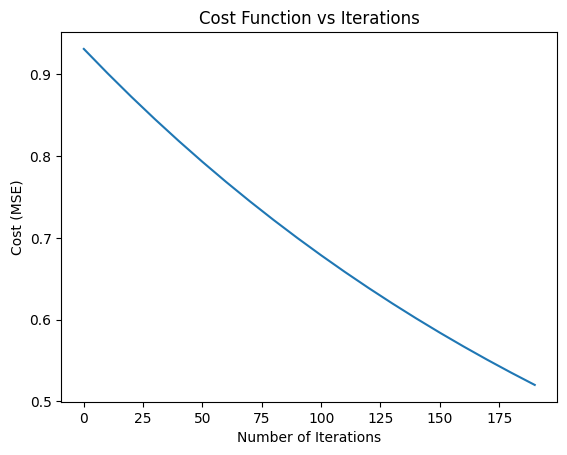

In [18]:
plt.plot(gd_iterations_df['iteration'], gd_iterations_df['cost'])
plt.xlabel('Number of Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Cost Function vs Iterations')
plt.show()

In [19]:
print(f"Final Estimates of b and w: {b}, {w}")

Final Estimates of b and w: 0.42844895817391443, [0.5319735  0.31601458 0.44142689]


This means that for a one standard deviation increase in TV spend, sales revenue increases by approximately 0.532 standard deviations, holding the other advertising channels constant.